<a href="https://colab.research.google.com/github/mp1605/CS-4410-Intro-to-Machine-Learning-/blob/main/Extra_Credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extra Credit Assignment: Image Classification with Pretrained ResNet18


## 1. Imports and GPU verification

In [8]:
import base64
import io
import sys
import torch
import torchvision
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Python:', sys.version.split()[0])
print('PyTorch:', torch.__version__)
print('Torchvision:', torchvision.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('ACTION REQUIRED for submission: enable a Colab GPU, then run all cells again.')

Python: 3.13.15
PyTorch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
CUDA available: True
Device: cuda
GPU: Tesla T4


## 2. Load the pretrained model
The weights supply both the 1,000 class names and the matching preprocessing: resize, center crop to 224 × 224, conversion to a tensor, and ImageNet normalization. Evaluation mode and inference mode are used for prediction.

In [9]:
weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights).to(device)
model.eval()
preprocess = weights.transforms()
categories = weights.meta['categories']
print('Model: ResNet18')
print('Weights:', weights.name)
print('Number of classes:', len(categories))
print('Model device:', next(model.parameters()).device)

Model: ResNet18
Weights: IMAGENET1K_V1
Number of classes: 1000
Model device: cuda:0


## 3. Load three embedded images
The following cell contains encoded image data, which makes this notebook self-contained apart from the pretrained weight download. You do not need to edit it.

Image sources:
- [Dog](https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg)
- [Bus](https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg)
- [Coffee](https://raw.githubusercontent.com/scikit-image/scikit-image/v0.19.3/skimage/data/coffee.png)

In [10]:
image_assets = [{'name': 'Dog', 'url': 'https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg', 'image_b64': '...'}, {'name': 'Bus', 'url': 'https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg', 'image_b64': '...'}, {'name': 'Coffee', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.19.3/skimage/data/coffee.png', 'image_b64': '...'}]
images = [Image.open(io.BytesIO(base64.b64decode(item['image_b64']))).convert('RGB')
          for item in image_assets]
print('Loaded:', ', '.join(item['name'] for item in image_assets))
assert len(images) >= 3


Loaded: Dog, Bus, Coffee


## 4. Predict the top five classes
Softmax converts logits to scores that sum to one across all 1,000 classes. The five displayed scores need not sum to 100%, and a high score is not a guarantee that the prediction is correct.

In [11]:
batch = torch.stack([preprocess(image) for image in images]).to(device)
with torch.inference_mode():
    probabilities = model(batch).softmax(dim=1)
    top_probs, top_ids = probabilities.topk(5, dim=1)
top_probs = top_probs.cpu()
top_ids = top_ids.cpu()
results = []
for i, asset in enumerate(image_assets):
    predictions = [(categories[index], float(score) * 100)
                   for score, index in zip(top_probs[i], top_ids[i])]
    results.append(predictions)
    print(f"\n{asset['name']} — Top-5 predictions")
    for rank, (label, percent) in enumerate(predictions, start=1):
        print(f'{rank}. {label}: {percent:.2f}%')
assert probabilities.shape == (3, 1000)
assert all(len(predictions) == 5 for predictions in results)



Dog — Top-5 predictions
1. Samoyed: 87.55%
2. white wolf: 5.11%
3. Arctic fox: 4.78%
4. Great Pyrenees: 0.52%
5. Pomeranian: 0.52%

Bus — Top-5 predictions
1. minibus: 83.94%
2. police van: 10.66%
3. recreational vehicle: 0.78%
4. trolleybus: 0.64%
5. ambulance: 0.59%

Coffee — Top-5 predictions
1. espresso: 85.21%
2. consomme: 4.44%
3. chocolate sauce: 3.72%
4. soup bowl: 2.27%
5. cup: 1.96%


## 5. Individual images and results


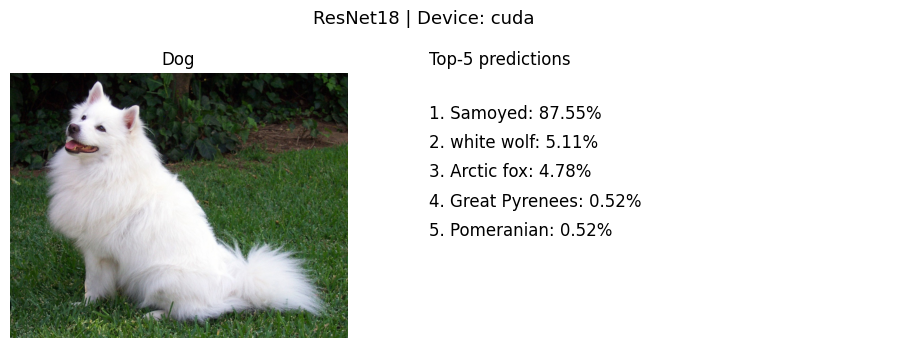

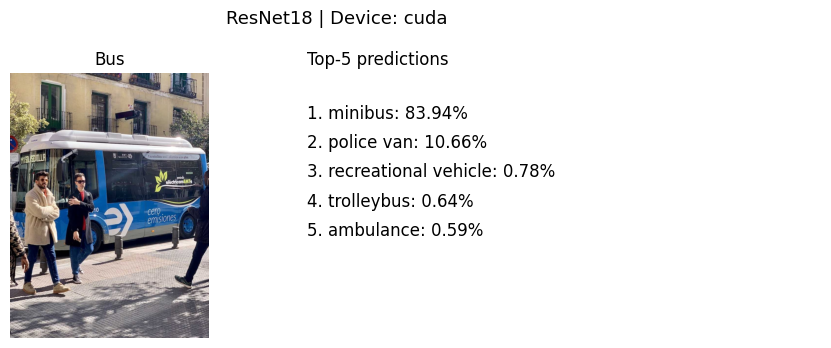

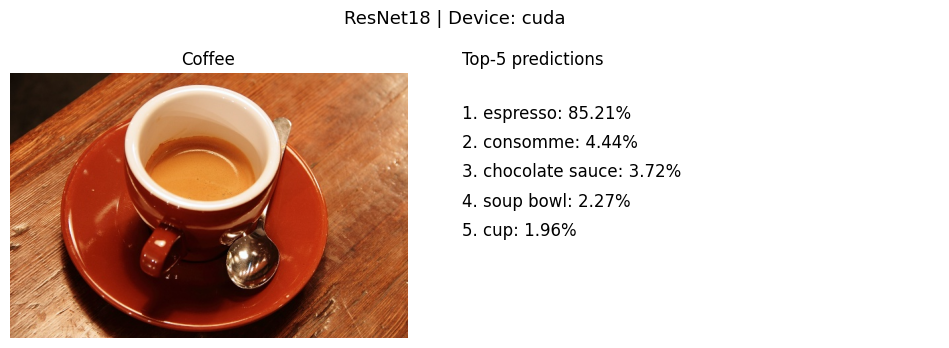

In [12]:
for asset, image, predictions in zip(image_assets, images, results):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].imshow(image)
    axes[0].set_title(asset['name'])
    axes[0].axis('off')
    lines = '\n'.join(f'{rank}. {label}: {percent:.2f}%'
                      for rank, (label, percent) in enumerate(predictions, 1))
    axes[1].axis('off')
    axes[1].set_title('Top-5 predictions', loc='left')
    axes[1].text(0, 0.88, lines, va='top', fontsize=12, linespacing=1.8)
    fig.suptitle(f'ResNet18 | Device: {device}', fontsize=13)
    plt.tight_layout()
    plt.show()


## 6. Interpret the results
# New Section

In [13]:
for asset, predictions in zip(image_assets, results):
    first, second = predictions[:2]
    print(f"{asset['name']}: the top prediction is '{first[0]}' ({first[1]:.2f}%). "
          f"The second prediction is '{second[0]}' ({second[1]:.2f}%). "
          f"The gap is {first[1] - second[1]:.2f} percentage points.")
print('\nConfidence scores describe the model output, not measured accuracy on a test dataset.')


Dog: the top prediction is 'Samoyed' (87.55%). The second prediction is 'white wolf' (5.11%). The gap is 82.44 percentage points.
Bus: the top prediction is 'minibus' (83.94%). The second prediction is 'police van' (10.66%). The gap is 73.29 percentage points.
Coffee: the top prediction is 'espresso' (85.21%). The second prediction is 'consomme' (4.44%). The gap is 80.78 percentage points.

Confidence scores describe the model output, not measured accuracy on a test dataset.


**Discussion:** A specific dog breed can be a reasonable label for the dog. For the bus image, the model predicts a single ImageNet class even though the scene also contains people and other objects. For the coffee image, the cup, drink, and surrounding objects can influence the ranking. Related classes can share probability. These examples demonstrate pretrained inference; they do not provide a reliable estimate of overall accuracy. The model is limited to its 1,000 ImageNet categories.




## References
- [Torchvision models and pretrained weights](https://docs.pytorch.org/vision/stable/models.html)
- [ResNet18 weights and preprocessing](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html)
- [PyTorch transfer learning tutorial](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

The images' original source URLs are listed in Section 3. No model weights or large datasets need to be uploaded to GitHub.